In [222]:
import cv2
import numpy as np
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [223]:
class MNIST_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 10)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [224]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = MNIST_CNN().to(device)
model.load_state_dict(torch.load("mnist_model.pth", map_location=device))
model.eval()


C:\Users\Shail Patel\AppData\Local\Temp\ipykernel_10568\1376409109.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("mnist_model.pth", ma

MNIST_CNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=6272, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=10, bias=True)


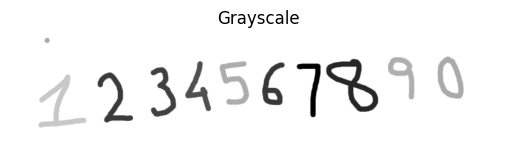

In [232]:
image = cv2.imread("images/numbers/digital/multiple/1234567890_colored.png")
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis('off')
plt.show()

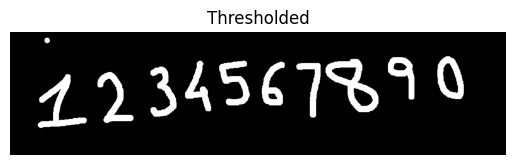

In [233]:
_, thresh = cv2.threshold(
    gray,
    0,
    255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_TRIANGLE
    # makes digits white + automatically chooses threshold
)

plt.imshow(thresh, cmap="gray")
plt.axis('off')
plt.title("Thresholded")
plt.show()

In [234]:
contours, _ = cv2.findContours(
	thresh,
	cv2.RETR_EXTERNAL,
	cv2.CHAIN_APPROX_SIMPLE
)

In [235]:
boxes = []

for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)
    
    # Filter tiny noise
    if w > 10 and h > 20:
        boxes.append((x, y, w, h))

In [236]:
boxes = sorted(boxes, key=lambda b: b[0])	# sorting left to right

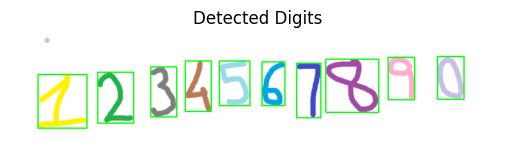

In [237]:
image_copy = image.copy()

for (x, y, w, h) in boxes:
    cv2.rectangle(image_copy, (x, y), (x+w, y+h), (0,255,0), 2)

plt.imshow(cv2.cvtColor(image_copy, cv2.COLOR_BGR2RGB))
plt.title("Detected Digits")
plt.axis('off')
plt.show()


In [238]:
predictions = []

for (x, y, w, h) in boxes:
        
    # Resize to 28x28
    digit = thresh[y:y+h, x:x+w]

    # Resize while keeping aspect ratio
    if h > w:
        new_h = 20
        new_w = int(w * (20 / h))
    else:
        new_w = 20
        new_h = int(h * (20 / w))

    digit = cv2.resize(digit, (new_w, new_h))

    # Create blank 28x28 image
    canvas = np.zeros((28, 28), dtype=np.uint8)

    # Compute center offsets
    x_offset = (28 - new_w) // 2
    y_offset = (28 - new_h) // 2

    canvas[y_offset:y_offset+new_h, x_offset:x_offset+new_w] = digit

    digit = canvas

    digit = torch.tensor(digit).float().unsqueeze(0).unsqueeze(0)
    
    # Normalize MNIST
    digit = transforms.Normalize((0.1307,), (0.3081,))(digit)
    
    digit = digit.to(device)
    
    with torch.no_grad():
        output = model(digit)
        pred = output.argmax(dim=1).item()
    
    predictions.append(str(pred))


In [239]:
final_number = "".join(predictions)
print("Predicted sequence:", final_number)


Predicted sequence: 1234567890
